In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

In [16]:
data = pd.read_csv(f'data.csv')
data

,duplicate_count,sequence_id,sequence,sequence_aa,locus,stop_codon,vj_in_frame,v_frameshift,productive,rev_comp,...,best_v_germline_alignment,best_v_germline_alignment_aa,best_c_call,pgen,sample,sample_id,condition,patient_id,tissue_type,pgen_log
0,6,SRR8052774.5117303,GTTCTGTCTCTCTGAGCCTCTGTTTCTCTCTGAGCTGAGCAGCCAC...,ELSSHHG*RSDALLLPLPKPPAPRPLPGLSPLLSPAG*WLWHGPLPRRL,IGH,T,F,F,F,F,...,GAGCTGAGCAGCC,ELSS,NaN,4.728253e-23,SRR8052774,GSM3427934,CTRL,32,healthy,-22.325299
1,5,SRR8052774.4867089,ATCGACAATGTCAAGAAGCAGATCTCCAACTTGCAGCAGTCCATCA...,AKNKLNDLEDALQQXPGPPAA*LPGADEHQAGPGSGDCHLQDPPGG...,IGH,T,T,F,F,F,...,ATTCCAAGAACACGCTGTATGTCC,SKNTLYV,NaN,4.458956e-48,SRR8052774,GSM3427934,CTRL,32,healthy,-47.350767
2,5,SRR8052774.27522431,GACAATGTCAAGAAGCAGATCTCCAACTTGCAGCAGTCCATCAGTG...,AKNKLNDLEDALQQAXPGPPAARLPGADEHQAGPGSGDCHLQDPPG...,IGH,F,T,F,T,F,...,ATTCCAAGAACACGCTGTATGTCC,SKNTLYV,NaN,6.696197e-51,SRR8052774,GSM3427934,CTRL,32,healthy,-50.174172
3,4,SRR8052774.8999002,ATCGACAATGTCAAGAAGCAGATCTCCAACTTGCAGCAGTCCATCA...,AKNKLNDLEDALQQXTWPACCVTTRS**TPSWPWIWRLPPTGPSWR...,IGH,T,F,F,F,F,...,ATTCCAAGAACACGCTGTATGTCC,SKNTLYV,NaN,2.375272e-54,SRR8052774,GSM3427934,CTRL,32,healthy,-53.624287
4,3,SRR8052774.17026979,CGACAATGTCAAGAAGCAGATCTCCAACTTGCAGCAGTCCATCAGT...,AKNKLNDLEDALQQAPAARLPGADEHQAGPGSGDCHLQDPPGGRRK...,IGH,F,T,F,T,F,...,ATTCCAAGAACACGCTGTATGTCC,SKNTLYV,NaN,4.608249e-46,SRR8052774,GSM3427934,CTRL,32,healthy,-45.336464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16167,1,SRR8052850.5814296,CAGACATCTGTGTACTTCTGTGCCAGCAGTGCGGGCGCTCCGATGG...,QTSVYFCASSAGAPMGEQFFGPGTRLTVLEDLKNVFPPEVAVFE,TRB,F,T,F,T,F,...,CAGACATCTGTGTACTTCTGTGCCAGCAGTG,QTSVYFCASS,TRBC2,1.972699e-11,SRR8052850,GSM3428010,AD,35,chronic_lesion,-10.704939
16168,1,SRR8052850.7813620,GTGTACTTCTGTGCCAGCAGTGCCCCCGGGACACTATACGAGCAGT...,VYFCASSAPGTLYEQYFGPGTRLTVTEDLKNVFPPEVAVFE,TRB,F,T,F,T,F,...,GTGTACTTCTGTGCCAGCAGTG,VYFCASS,TRBC2,1.079219e-08,SRR8052850,GSM3428010,AD,35,chronic_lesion,-7.966890
16169,1,SRR8052850.22894727,CTCAGCCGTGTATCTCTGTGCCAGCAGCCCATCCGGGAAGTACAAT...,SAVYLCASSPSGKYNEQFFGPGTRLTVLEDLKNVFPPEVAVFEPSE...,TRB,F,T,F,T,F,...,CTCAGCCGTGTATCTCTGTGCCAGCAGC,SAVYLCASS,TRBC2,5.882478e-08,SRR8052850,GSM3428010,AD,35,chronic_lesion,-7.230440
16170,1,SRR8052850.460773,AGCGCACACAGCAGGAGGACTCCGCCGTGTATCTCTGTGCCAGCAG...,RTQQEDSAVYLCASSTHRGPAEKLFFGSGTQLSVLEDLNKVFPPEV...,TRB,F,T,F,T,F,...,AGCGCACACAGCAGGAGGACTCCGCCGTGTATCTCTGTGCCAGCAGC,RTQQEDSAVYLCASS,TRBC1,1.505610e-10,SRR8052850,GSM3428010,AD,35,chronic_lesion,-9.822287


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

def analyze_immune_data_comparison(df, condition, pgen_threshold=-50, patient_id=None):
    """
    Analyze immune repertoire data comparing conditions and tissue types.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with immune data
    condition : str
        Condition to compare with CTRL ('PSO' or 'AD')
    pgen_threshold : float, default=-50
        Minimum threshold for pgen_log
    patient_id : int or list or None, default=None
        Specific patient(s) to analyze. If None, analyze all patients
    
    Returns:
    --------
    tuple: (comparison_dataframes_dict, clustering_data_dict)
    """
    
    # Validate condition parameter
    if condition not in ['PSO', 'AD']:
        raise ValueError("Condition must be 'PSO' or 'AD'")
    
    # Create output directory if it doesn't exist
    import os
    os.makedirs('output', exist_ok=True)
    
    # Filter by pgen_threshold
    filtered_df = df[df['pgen_log'] >= pgen_threshold].copy()
    
    # Filter by patient_id if specified
    if patient_id is not None:
        if isinstance(patient_id, (int, str)):
            filtered_df = filtered_df[filtered_df['patient_id'] == patient_id]
        elif isinstance(patient_id, list):
            filtered_df = filtered_df[filtered_df['patient_id'].isin(patient_id)]
    
    def extract_v_gene_info(v_call):
        """
        Extract locus (first 3 letters) and family (letters until first digit after locus)
        Examples:
        - IGHV3-64*03 -> locus: IGH, family: IGHV3
        - TRAV26-1*01 -> locus: TRA, family: TRAV26
        - IGKV1-5*01 -> locus: IGK, family: IGKV1
        """
        if pd.isna(v_call):
            return None, None
        
        try:
            # Take first call if multiple separated by comma
            v_call = str(v_call).split(',')[0].strip()
            
            # Extract locus (first 3 letters)
            locus = v_call[:3]
            
            # Extract family: letters followed by digits until next non-alphanumeric
            # Find position of first digit after letters
            import re
            family_match = re.match(r'([A-Z]+[0-9]+)', v_call)
            if family_match:
                family = family_match.group(1)
            else:
                # Fallback: take until first non-letter
                family_match = re.match(r'([A-Z]+)', v_call)
                family = family_match.group(1) if family_match else None
            
            return locus, family
        except:
            return None, None
    
    # Apply extraction
    extracted_info = filtered_df['best_v_call'].apply(extract_v_gene_info)
    filtered_df['v_locus'] = extracted_info.apply(lambda x: x[0] if x else None)
    filtered_df['v_family'] = extracted_info.apply(lambda x: x[1] if x else None)
    
    # Remove rows with None in v_locus or v_family
    filtered_df = filtered_df.dropna(subset=['v_locus', 'v_family'])
    
    # Initialize results storage
    comparison_results = []
    log2fc_results = []
    
    # Get unique patients for the specified condition and CTRL
    cond_patients = filtered_df[filtered_df['condition'] == condition]['patient_id'].unique()
    ctrl_patients = filtered_df[filtered_df['condition'] == 'CTRL']['patient_id'].unique()
    
    # Find patients that have both condition data and CTRL data
    patients_to_analyze = list(set(cond_patients).intersection(set(ctrl_patients)))
    
    if not patients_to_analyze:
        print(f"No patients found with both {condition} and CTRL data")
        return {}, {}
    
    print(f"Analyzing {len(patients_to_analyze)} patients...")
    
    for patient in patients_to_analyze:
        # Get patient data for both conditions
        patient_cond_data = filtered_df[
            (filtered_df['patient_id'] == patient) & 
            (filtered_df['condition'] == condition)
        ]
        patient_ctrl_data = filtered_df[
            (filtered_df['patient_id'] == patient) & 
            (filtered_df['condition'] == 'CTRL')
        ]
        
        # Get tissue types available
        cond_tissues = patient_cond_data['tissue_type'].unique()
        ctrl_tissues = patient_ctrl_data['tissue_type'].unique()
        
        # Skip if no tissue types
        if len(cond_tissues) == 0 or len(ctrl_tissues) == 0:
            continue
        
        # Define comparison pairs
        comparisons = []
        
        # Healthy (CTRL) vs non-lesional (condition)
        if 'healthy' in ctrl_tissues and 'non-lesional' in cond_tissues:
            comparisons.append(('healthy', 'non-lesional'))
        
        # Healthy (CTRL) vs lesional (condition)
        if 'healthy' in ctrl_tissues and 'lesional' in cond_tissues:
            comparisons.append(('healthy', 'lesional'))
        
        # Lesional vs non-lesional (within condition)
        if 'lesional' in cond_tissues and 'non-lesional' in cond_tissues:
            comparisons.append(('lesional', 'non-lesional'))
        
        for tissue1, tissue2 in comparisons:
            # Get data for each tissue
            if tissue1 == 'healthy':
                data1 = patient_ctrl_data[patient_ctrl_data['tissue_type'] == tissue1]
                cond1 = 'CTRL'
            else:
                data1 = patient_cond_data[patient_cond_data['tissue_type'] == tissue1]
                cond1 = condition
            
            if tissue2 == 'healthy':
                data2 = patient_ctrl_data[patient_ctrl_data['tissue_type'] == tissue2]
                cond2 = 'CTRL'
            else:
                data2 = patient_cond_data[patient_cond_data['tissue_type'] == tissue2]
                cond2 = condition
            
            # Skip if either dataset is empty
            if len(data1) == 0 or len(data2) == 0:
                continue
            
            # Count v-genes by family and locus
            # By family
            family_counts1 = data1['v_family'].value_counts()
            family_counts2 = data2['v_family'].value_counts()
            
            # By locus
            locus_counts1 = data1['v_locus'].value_counts()
            locus_counts2 = data2['v_locus'].value_counts()
            
            # Get union of all families and loci
            all_families = set(family_counts1.index).union(set(family_counts2.index))
            all_loci = set(locus_counts1.index).union(set(locus_counts2.index))
            
            # Calculate for families
            for family in all_families:
                count1 = family_counts1.get(family, 0)
                count2 = family_counts2.get(family, 0)
                
                # Calculate change
                change = count2 - count1
                if count1 > 0:
                    percent_change = (change / count1) * 100
                else:
                    percent_change = float('inf') if count2 > 0 else 0
                
                # Store results
                comparison_results.append({
                    'patient': patient,
                    'comparison': f'{tissue1}_vs_{tissue2}',
                    'type': 'family',
                    'name': family,
                    'count_condition1': count1,
                    'count_condition2': count2,
                    'change': change,
                    'percent_change': percent_change,
                    'condition1': cond1,
                    'condition2': cond2,
                    'tissue1': tissue1,
                    'tissue2': tissue2
                })
            
            # Calculate for loci
            for locus in all_loci:
                count1 = locus_counts1.get(locus, 0)
                count2 = locus_counts2.get(locus, 0)
                
                # Calculate change
                change = count2 - count1
                if count1 > 0:
                    percent_change = (change / count1) * 100
                else:
                    percent_change = float('inf') if count2 > 0 else 0
                
                # Store results
                comparison_results.append({
                    'patient': patient,
                    'comparison': f'{tissue1}_vs_{tissue2}',
                    'type': 'locus',
                    'name': locus,
                    'count_condition1': count1,
                    'count_condition2': count2,
                    'change': change,
                    'percent_change': percent_change,
                    'condition1': cond1,
                    'condition2': cond2,
                    'tissue1': tissue1,
                    'tissue2': tissue2
                })
            
            # Calculate log2fc
            total1 = len(data1)
            total2 = len(data2)
            
            # Log2FC for families
            for family in all_families:
                count1 = family_counts1.get(family, 0)
                count2 = family_counts2.get(family, 0)
                
                # Calculate log2fc with pseudocount
                if total1 > 0 and total2 > 0:
                    log2fc = np.log2((count2 + 0.5) / total2) - np.log2((count1 + 0.5) / total1)
                else:
                    log2fc = np.nan
                
                # Store log2fc results
                log2fc_results.append({
                    'patient': patient,
                    'comparison': f'{tissue1}_vs_{tissue2}',
                    'type': 'family',
                    'name': family,
                    'log2fc': log2fc,
                    'count1': count1,
                    'count2': count2,
                    'total1': total1,
                    'total2': total2,
                    'tissue1': tissue1,
                    'tissue2': tissue2
                })
            
            # Log2FC for loci
            for locus in all_loci:
                count1 = locus_counts1.get(locus, 0)
                count2 = locus_counts2.get(locus, 0)
                
                # Calculate log2fc with pseudocount
                if total1 > 0 and total2 > 0:
                    log2fc = np.log2((count2 + 0.5) / total2) - np.log2((count1 + 0.5) / total1)
                else:
                    log2fc = np.nan
                
                # Store log2fc results
                log2fc_results.append({
                    'patient': patient,
                    'comparison': f'{tissue1}_vs_{tissue2}',
                    'type': 'locus',
                    'name': locus,
                    'log2fc': log2fc,
                    'count1': count1,
                    'count2': count2,
                    'total1': total1,
                    'total2': total2,
                    'tissue1': tissue1,
                    'tissue2': tissue2
                })
    
    # Create dataframes
    comparison_df = pd.DataFrame(comparison_results)
    log2fc_df = pd.DataFrame(log2fc_results)
    
    # Save output files
    output_files = {}
    
    for comparison_type in comparison_df['comparison'].unique():
        comp_data = comparison_df[comparison_df['comparison'] == comparison_type]
        filename = f'output/output_1_{condition}_{comparison_type}.csv'
        comp_data.to_csv(filename, index=False)
        output_files[f'comparison_{comparison_type}'] = filename
        
        comp_log2fc = log2fc_df[log2fc_df['comparison'] == comparison_type]
        filename2 = f'output/output_2_{condition}_{comparison_type}.csv'
        comp_log2fc.to_csv(filename2, index=False)
        output_files[f'log2fc_{comparison_type}'] = filename2
    
    # Create cluster maps - DISPLAY IN CONSOLE
    clustering_results = {}
    
    # Prepare data for clustering - by families
    family_log2fc_pivot = log2fc_df[
        (log2fc_df['type'] == 'family') & 
        (log2fc_df['comparison'].str.contains('lesional'))
    ].pivot_table(
        index='name',
        columns='patient',
        values='log2fc',
        aggfunc='mean'
    ).fillna(0)
    
    # Prepare data for clustering - by loci
    locus_log2fc_pivot = log2fc_df[
        (log2fc_df['type'] == 'locus') & 
        (log2fc_df['comparison'].str.contains('lesional'))
    ].pivot_table(
        index='name',
        columns='patient',
        values='log2fc',
        aggfunc='mean'
    ).fillna(0)
    
    # Create and display clustering plots
    if not family_log2fc_pivot.empty and len(family_log2fc_pivot) > 1:
        print(f"\n{'='*60}")
        print(f"V-GENE FAMILY CLUSTER MAP ({condition} vs CTRL)")
        print('='*60)
        
        fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
        
        # Heatmap for families
        sns.heatmap(family_log2fc_pivot, ax=ax1, cmap='RdBu_r', center=0,
                   cbar_kws={'label': 'Log2FC'}, annot=True, fmt='.2f',
                   linewidths=0.5)
        ax1.set_title(f'Family-wise Log2FC Heatmap ({condition} vs CTRL)')
        ax1.set_xlabel('Patient ID')
        ax1.set_ylabel('V-Gene Family')
        
        # Hierarchical clustering dendrogram for families
        if len(family_log2fc_pivot) > 2:
            try:
                linkage_matrix = linkage(family_log2fc_pivot, method='ward')
                dendrogram(linkage_matrix, labels=family_log2fc_pivot.index.tolist(),
                          ax=ax2, orientation='left', leaf_font_size=10)
                ax2.set_title('Hierarchical Clustering of V-Gene Families')
                ax2.set_xlabel('Distance')
            except:
                ax2.text(0.5, 0.5, 'Insufficient data for clustering',
                        ha='center', va='center', transform=ax2.transAxes)
        
        plt.tight_layout()
        plt.show()
        
        # Also save to file
        plt.savefig(f'output/family_clustering_{condition}.png', dpi=300, bbox_inches='tight')
        clustering_results['family_clustering'] = f'output/family_clustering_{condition}.png'
        
        # Display family clustering summary
        print(f"\nFamily Clustering Summary:")
        print(f"Number of families: {len(family_log2fc_pivot)}")
        print(f"Number of patients: {len(family_log2fc_pivot.columns)}")
        print("\nTop 10 families by absolute Log2FC:")
        family_abs_fc = family_log2fc_pivot.abs().mean(axis=1).sort_values(ascending=False)
        for family, fc in family_abs_fc.head(10).items():
            print(f"  {family}: mean |Log2FC| = {fc:.3f}")
    
    if not locus_log2fc_pivot.empty and len(locus_log2fc_pivot) > 1:
        print(f"\n{'='*60}")
        print(f"V-GENE LOCUS CLUSTER MAP ({condition} vs CTRL)")
        print('='*60)
        
        fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Heatmap for loci
        sns.heatmap(locus_log2fc_pivot, ax=ax1, cmap='RdBu_r', center=0,
                   cbar_kws={'label': 'Log2FC'}, annot=True, fmt='.2f',
                   linewidths=0.5)
        ax1.set_title(f'Locus-wise Log2FC Heatmap ({condition} vs CTRL)')
        ax1.set_xlabel('Patient ID')
        ax1.set_ylabel('V-Gene Locus')
        
        # Hierarchical clustering dendrogram for loci
        if len(locus_log2fc_pivot) > 2:
            try:
                linkage_matrix = linkage(locus_log2fc_pivot, method='ward')
                dendrogram(linkage_matrix, labels=locus_log2fc_pivot.index.tolist(),
                          ax=ax2, orientation='left', leaf_font_size=10)
                ax2.set_title('Hierarchical Clustering of V-Gene Loci')
                ax2.set_xlabel('Distance')
            except:
                ax2.text(0.5, 0.5, 'Insufficient data for clustering',
                        ha='center', va='center', transform=ax2.transAxes)
        
        plt.tight_layout()
        plt.show()
        
        # Also save to file
        plt.savefig(f'output/locus_clustering_{condition}.png', dpi=300, bbox_inches='tight')
        clustering_results['locus_clustering'] = f'output/locus_clustering_{condition}.png'
        
        # Display locus clustering summary
        print(f"\nLocus Clustering Summary:")
        print(f"Number of loci: {len(locus_log2fc_pivot)}")
        print(f"Number of patients: {len(locus_log2fc_pivot.columns)}")
        print("\nTop loci by absolute Log2FC:")
        locus_abs_fc = locus_log2fc_pivot.abs().mean(axis=1).sort_values(ascending=False)
        for locus, fc in locus_abs_fc.head(10).items():
            print(f"  {locus}: mean |Log2FC| = {fc:.3f}")
    
    # Create summary statistics
    summary_stats = {
        'total_patients_analyzed': len(patients_to_analyze),
        'condition': condition,
        'pgen_threshold': pgen_threshold,
        'comparisons_performed': comparison_df['comparison'].unique().tolist(),
        'unique_families': comparison_df[comparison_df['type'] == 'family']['name'].nunique(),
        'unique_loci': comparison_df[comparison_df['type'] == 'locus']['name'].nunique(),
        'output_files': output_files
    }
    
    # Save summary
    summary_df = pd.DataFrame([summary_stats])
    summary_df.to_csv(f'output/summary_{condition}.csv', index=False)
    
    print(f"\n{'='*60}")
    print(f"ANALYSIS COMPLETE FOR {condition} vs CTRL")
    print('='*60)
    print(f"Patients analyzed: {len(patients_to_analyze)}")
    print(f"Comparisons performed: {len(comparison_df['comparison'].unique())}")
    print(f"Unique V-gene families: {comparison_df[comparison_df['type'] == 'family']['name'].nunique()}")
    print(f"Unique V-gene loci: {comparison_df[comparison_df['type'] == 'locus']['name'].nunique()}")
    print(f"Output files saved in 'output/' directory")
    
    return comparison_df, log2fc_df, clustering_results, summary_stats


def display_comparison_tables(comparison_df, log2fc_df, condition, n_rows=10):
    """
    Display sample comparison tables in console.
    """
    print(f"\n{'='*60}")
    print(f"SAMPLE COMPARISON TABLES FOR {condition}")
    print('='*60)
    
    # Display comparison table (output_1) samples
    print("\n1. COUNT COMPARISONS (output_1.csv samples):")
    for comparison_type in comparison_df['comparison'].unique()[:2]:
        print(f"\n   Comparison: {comparison_type}")
        comp_data = comparison_df[comparison_df['comparison'] == comparison_type]
        
        # Show family comparisons
        family_data = comp_data[comp_data['type'] == 'family'].head(n_rows)
        if not family_data.empty:
            print(f"\n   V-Gene Families (top {n_rows}):")
            for _, row in family_data.iterrows():
                print(f"     {row['name']}: {row['count_condition1']} → {row['count_condition2']} "
                      f"(Δ={row['change']}, {row['percent_change']:.1f}%)")
    
    # Display log2fc table (output_2) samples
    print("\n\n2. LOG2FC VALUES (output_2.csv samples):")
    for comparison_type in log2fc_df['comparison'].unique()[:2]:
        print(f"\n   Comparison: {comparison_type}")
        log2fc_data = log2fc_df[log2fc_df['comparison'] == comparison_type]
        
        # Show family log2fc
        family_log2fc = log2fc_data[log2fc_data['type'] == 'family'].head(n_rows)
        if not family_log2fc.empty:
            print(f"\n   V-Gene Families Log2FC (top {n_rows}):")
            for _, row in family_log2fc.iterrows():
                print(f"     {row['name']}: Log2FC = {row['log2fc']:.3f}")


def generate_detailed_report(comparison_df, log2fc_df, condition):
    """
    Generate a detailed report of the analysis results.
    """
    report = []
    report.append(f"\n{'='*60}")
    report.append(f"DETAILED ANALYSIS REPORT FOR {condition} vs CTRL")
    report.append('='*60)
    
    # Summary statistics
    report.append(f"\n1. SUMMARY STATISTICS:")
    report.append(f"   Total comparisons: {len(comparison_df)}")
    report.append(f"   Unique patients: {comparison_df['patient'].nunique()}")
    report.append(f"   Unique V-gene families: {comparison_df[comparison_df['type'] == 'family']['name'].nunique()}")
    report.append(f"   Unique V-gene loci: {comparison_df[comparison_df['type'] == 'locus']['name'].nunique()}")
    
    # Most changed families
    report.append(f"\n2. TOP 10 MOST CHANGED V-GENE FAMILIES:")
    family_changes = comparison_df[comparison_df['type'] == 'family']
    if not family_changes.empty:
        top_families = family_changes.groupby('name')['change'].mean().abs().nlargest(10)
        for family, change in top_families.items():
            report.append(f"   {family}: mean absolute change = {change:.2f}")
    
    # Most changed loci
    report.append(f"\n3. TOP 10 MOST CHANGED V-GENE LOCI:")
    locus_changes = comparison_df[comparison_df['type'] == 'locus']
    if not locus_changes.empty:
        top_loci = locus_changes.groupby('name')['change'].mean().abs().nlargest(10)
        for locus, change in top_loci.items():
            report.append(f"   {locus}: mean absolute change = {change:.2f}")
    
    # Most significant log2fc families
    report.append(f"\n4. TOP 10 MOST SIGNIFICANT FAMILY Log2FC VALUES:")
    family_log2fc = log2fc_df[log2fc_df['type'] == 'family']
    if not family_log2fc.empty:
        top_family_fc = family_log2fc.groupby('name')['log2fc'].mean().abs().nlargest(10)
        for family, fc in top_family_fc.items():
            report.append(f"   {family}: mean |Log2FC| = {fc:.3f}")
    
    # Most significant log2fc loci
    report.append(f"\n5. TOP 10 MOST SIGNIFICANT LOCUS Log2FC VALUES:")
    locus_log2fc = log2fc_df[log2fc_df['type'] == 'locus']
    if not locus_log2fc.empty:
        top_locus_fc = locus_log2fc.groupby('name')['log2fc'].mean().abs().nlargest(10)
        for locus, fc in top_locus_fc.items():
            report.append(f"   {locus}: mean |Log2FC| = {fc:.3f}")
    
    # Print to console
    for line in report:
        print(line)
    
    # Save report
    with open(f'output/detailed_report_{condition}.txt', 'w') as f:
        f.write('\n'.join(report))
    
    return report


def create_simple_clustermap_console(log2fc_df, condition, feature_type='family'):
    """
    Create a simple clustermap displayed directly in console as a heatmap-like text.
    """
    print(f"\n{'='*60}")
    print(f"SIMPLE TEXT CLUSTERMAP FOR {feature_type.upper()} ({condition})")
    print('='*60)
    
    # Filter data
    filtered_data = log2fc_df[
        (log2fc_df['type'] == feature_type) & 
        (log2fc_df['comparison'].str.contains('lesional'))
    ]
    
    if filtered_data.empty:
        print(f"No data available for {feature_type} clustermap")
        return
    
    # Create pivot table
    pivot_data = filtered_data.pivot_table(
        index='name',
        columns='patient',
        values='log2fc',
        aggfunc='mean'
    ).fillna(0)
    
    if len(pivot_data) < 2 or len(pivot_data.columns) < 2:
        print(f"Insufficient data for {feature_type} clustermap")
        return
    
    # Create simple text-based heatmap
    print(f"\nHeatmap (rows: {feature_type}s, columns: patients):")
    print("-" * (len(pivot_data.columns) * 10 + 5))
    
    # Print header
    header = f"{'':15}"
    for patient in pivot_data.columns:
        header += f"{patient:>8}"
    print(header)
    
    # Print each row
    for feature in pivot_data.index[:20]:  # Limit to first 20 features
        row_str = f"{feature:15}"
        for patient in pivot_data.columns:
            value = pivot_data.loc[feature, patient]
            # Create simple visualization
            if value > 1:
                symbol = "++"
            elif value > 0.5:
                symbol = "+"
            elif value > 0:
                symbol = "."
            elif value < -1:
                symbol = "--"
            elif value < -0.5:
                symbol = "-"
            elif value < 0:
                symbol = "."
            else:
                symbol = "0"
            row_str += f"{symbol:>8}"
        print(row_str)
    
    print("\nLegend: ++ = >1.0, + = 0.5-1.0, . = 0-0.5, - = -0.5-0, -- = <-0.5, 0 = 0")


1. Load your data:
   import pandas as pd
   df = pd.read_csv('your_immune_data.csv')

2. Run analysis for PSO:
   results = analyze_immune_data_comparison(df, condition='PSO')

3. Run analysis for AD:
   results = analyze_immune_data_comparison(df, condition='AD', pgen_threshold=-60)

4. For specific patients:
   results = analyze_immune_data_comparison(df, condition='PSO', patient_id=[32, 35])


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def analyze_immune_data_comparison(df, conditions=['AD', 'PSO'], pgen_threshold=-50, patient_id=None):
    """
    Analyze immune repertoire data comparing conditions and tissue types.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with immune data
    conditions : list or str, default=['AD', 'PSO']
        Condition(s) to compare with CTRL ('PSO' and/or 'AD')
    pgen_threshold : float, default=-50
        Minimum threshold for pgen_log
    patient_id : int or list or None, default=None
        Specific patient(s) to analyze. If None, analyze all patients
    
    Returns:
    --------
    dict: Dictionary containing all analysis results for each condition
    """
    
    # Handle single condition input
    if isinstance(conditions, str):
        conditions = [conditions]
    
    # Validate conditions
    valid_conditions = ['PSO', 'AD']
    for cond in conditions:
        if cond not in valid_conditions:
            raise ValueError(f"Condition must be 'PSO' or 'AD', got '{cond}'")
    
    # Create output directory if it doesn't exist
    import os
    os.makedirs('output', exist_ok=True)
    
    # Store all results
    all_results = {}
    
    # Process each condition
    for condition in conditions:
        print(f"\n{'='*80}")
        print(f"ANALYZING {condition} vs CTRL")
        print('='*80)
        
        # Filter by pgen_threshold
        filtered_df = df[df['pgen_log'] >= pgen_threshold].copy()
        
        # Filter by patient_id if specified
        if patient_id is not None:
            if isinstance(patient_id, (int, str)):
                filtered_df = filtered_df[filtered_df['patient_id'] == patient_id]
            elif isinstance(patient_id, list):
                filtered_df = filtered_df[filtered_df['patient_id'].isin(patient_id)]
        
        def extract_v_gene_info(v_call):
            """
            Extract locus (first 3 letters) and family (letters until first digit after locus)
            Examples:
            - IGHV3-64*03 -> locus: IGH, family: IGHV3
            - TRAV26-1*01 -> locus: TRA, family: TRAV26
            - IGKV1-5*01 -> locus: IGK, family: IGKV1
            """
            if pd.isna(v_call):
                return None, None
            
            try:
                # Take first call if multiple separated by comma
                v_call = str(v_call).split(',')[0].strip()
                
                # Extract locus (first 3 letters)
                locus = v_call[:3]
                
                # Extract family: letters followed by digits until next non-alphanumeric
                # Find position of first digit after letters
                import re
                family_match = re.match(r'([A-Z]+[0-9]+)', v_call)
                if family_match:
                    family = family_match.group(1)
                else:
                    # Fallback: take until first non-letter
                    family_match = re.match(r'([A-Z]+)', v_call)
                    family = family_match.group(1) if family_match else None
                
                return locus, family
            except:
                return None, None
        
        # Apply extraction
        extracted_info = filtered_df['best_v_call'].apply(extract_v_gene_info)
        filtered_df['v_locus'] = extracted_info.apply(lambda x: x[0] if x else None)
        filtered_df['v_family'] = extracted_info.apply(lambda x: x[1] if x else None)
        
        # Remove rows with None in v_locus or v_family
        filtered_df = filtered_df.dropna(subset=['v_locus', 'v_family'])
        
        # Initialize results storage
        comparison_results = []
        log2fc_results = []
        
        # Get unique patients for the specified condition and CTRL
        cond_patients = filtered_df[filtered_df['condition'] == condition]['patient_id'].unique()
        ctrl_patients = filtered_df[filtered_df['condition'] == 'CTRL']['patient_id'].unique()
        
        # Find patients that have both condition data and CTRL data
        patients_to_analyze = list(set(cond_patients).intersection(set(ctrl_patients)))
        
        if not patients_to_analyze:
            print(f"No patients found with both {condition} and CTRL data")
            all_results[condition] = {}
            continue
        
        print(f"Analyzing {len(patients_to_analyze)} patients...")
        
        for patient in patients_to_analyze:
            # Get patient data for both conditions
            patient_cond_data = filtered_df[
                (filtered_df['patient_id'] == patient) & 
                (filtered_df['condition'] == condition)
            ]
            patient_ctrl_data = filtered_df[
                (filtered_df['patient_id'] == patient) & 
                (filtered_df['condition'] == 'CTRL')
            ]
            
            # Get tissue types available
            cond_tissues = patient_cond_data['tissue_type'].unique()
            ctrl_tissues = patient_ctrl_data['tissue_type'].unique()
            
            # Skip if no tissue types
            if len(cond_tissues) == 0 or len(ctrl_tissues) == 0:
                continue
            
            # Define comparison pairs
            comparisons = []
            
            # Healthy (CTRL) vs non-lesional (condition)
            if 'healthy' in ctrl_tissues and 'non-lesional' in cond_tissues:
                comparisons.append(('healthy', 'non-lesional'))
            
            # Healthy (CTRL) vs lesional (condition)
            if 'healthy' in ctrl_tissues and 'lesional' in cond_tissues:
                comparisons.append(('healthy', 'lesional'))
            
            # Lesional vs non-lesional (within condition)
            if 'lesional' in cond_tissues and 'non-lesional' in cond_tissues:
                comparisons.append(('lesional', 'non-lesional'))
            
            for tissue1, tissue2 in comparisons:
                # Get data for each tissue
                if tissue1 == 'healthy':
                    data1 = patient_ctrl_data[patient_ctrl_data['tissue_type'] == tissue1]
                    cond1 = 'CTRL'
                else:
                    data1 = patient_cond_data[patient_cond_data['tissue_type'] == tissue1]
                    cond1 = condition
                
                if tissue2 == 'healthy':
                    data2 = patient_ctrl_data[patient_ctrl_data['tissue_type'] == tissue2]
                    cond2 = 'CTRL'
                else:
                    data2 = patient_cond_data[patient_cond_data['tissue_type'] == tissue2]
                    cond2 = condition
                
                # Skip if either dataset is empty
                if len(data1) == 0 or len(data2) == 0:
                    continue
                
                # Count v-genes by family and locus
                # By family
                family_counts1 = data1['v_family'].value_counts()
                family_counts2 = data2['v_family'].value_counts()
                
                # By locus
                locus_counts1 = data1['v_locus'].value_counts()
                locus_counts2 = data2['v_locus'].value_counts()
                
                # Get union of all families and loci
                all_families = set(family_counts1.index).union(set(family_counts2.index))
                all_loci = set(locus_counts1.index).union(set(locus_counts2.index))
                
                # Calculate for families
                for family in all_families:
                    count1 = family_counts1.get(family, 0)
                    count2 = family_counts2.get(family, 0)
                    
                    # Calculate change
                    change = count2 - count1
                    if count1 > 0:
                        percent_change = (change / count1) * 100
                    else:
                        percent_change = float('inf') if count2 > 0 else 0
                    
                    # Store results
                    comparison_results.append({
                        'patient': patient,
                        'comparison': f'{tissue1}_vs_{tissue2}',
                        'type': 'family',
                        'name': family,
                        'count_condition1': count1,
                        'count_condition2': count2,
                        'change': change,
                        'percent_change': percent_change,
                        'condition1': cond1,
                        'condition2': cond2,
                        'tissue1': tissue1,
                        'tissue2': tissue2
                    })
                
                # Calculate for loci
                for locus in all_loci:
                    count1 = locus_counts1.get(locus, 0)
                    count2 = locus_counts2.get(locus, 0)
                    
                    # Calculate change
                    change = count2 - count1
                    if count1 > 0:
                        percent_change = (change / count1) * 100
                    else:
                        percent_change = float('inf') if count2 > 0 else 0
                    
                    # Store results
                    comparison_results.append({
                        'patient': patient,
                        'comparison': f'{tissue1}_vs_{tissue2}',
                        'type': 'locus',
                        'name': locus,
                        'count_condition1': count1,
                        'count_condition2': count2,
                        'change': change,
                        'percent_change': percent_change,
                        'condition1': cond1,
                        'condition2': cond2,
                        'tissue1': tissue1,
                        'tissue2': tissue2
                    })
                
                # Calculate log2fc
                total1 = len(data1)
                total2 = len(data2)
                
                # Log2FC for families
                for family in all_families:
                    count1 = family_counts1.get(family, 0)
                    count2 = family_counts2.get(family, 0)
                    
                    # Calculate log2fc with pseudocount
                    if total1 > 0 and total2 > 0:
                        log2fc = np.log2((count2 + 0.5) / total2) - np.log2((count1 + 0.5) / total1)
                    else:
                        log2fc = np.nan
                    
                    # Store log2fc results
                    log2fc_results.append({
                        'patient': patient,
                        'comparison': f'{tissue1}_vs_{tissue2}',
                        'type': 'family',
                        'name': family,
                        'log2fc': log2fc,
                        'count1': count1,
                        'count2': count2,
                        'total1': total1,
                        'total2': total2,
                        'tissue1': tissue1,
                        'tissue2': tissue2
                    })
                
                # Log2FC for loci
                for locus in all_loci:
                    count1 = locus_counts1.get(locus, 0)
                    count2 = locus_counts2.get(locus, 0)
                    
                    # Calculate log2fc with pseudocount
                    if total1 > 0 and total2 > 0:
                        log2fc = np.log2((count2 + 0.5) / total2) - np.log2((count1 + 0.5) / total1)
                    else:
                        log2fc = np.nan
                    
                    # Store log2fc results
                    log2fc_results.append({
                        'patient': patient,
                        'comparison': f'{tissue1}_vs_{tissue2}',
                        'type': 'locus',
                        'name': locus,
                        'log2fc': log2fc,
                        'count1': count1,
                        'count2': count2,
                        'total1': total1,
                        'total2': total2,
                        'tissue1': tissue1,
                        'tissue2': tissue2
                    })
        
        # Create dataframes
        comparison_df = pd.DataFrame(comparison_results)
        log2fc_df = pd.DataFrame(log2fc_results)
        
        # Save output files
        output_files = {}
        
        for comparison_type in comparison_df['comparison'].unique():
            comp_data = comparison_df[comparison_df['comparison'] == comparison_type]
            filename = f'output/output_1_{condition}_{comparison_type}.csv'
            comp_data.to_csv(filename, index=False)
            output_files[f'comparison_{comparison_type}'] = filename
            
            comp_log2fc = log2fc_df[log2fc_df['comparison'] == comparison_type]
            filename2 = f'output/output_2_{condition}_{comparison_type}.csv'
            comp_log2fc.to_csv(filename2, index=False)
            output_files[f'log2fc_{comparison_type}'] = filename2
        
        # Create clustermaps - DISPLAY IN CONSOLE
        clustering_results = {}
        
        # Prepare data for clustermaps - by families
        family_log2fc_pivot = log2fc_df[
            (log2fc_df['type'] == 'family') & 
            (log2fc_df['comparison'].str.contains('lesional'))
        ].pivot_table(
            index='name',
            columns='patient',
            values='log2fc',
            aggfunc='mean'
        ).fillna(0)
        
        # Prepare data for clustermaps - by loci
        locus_log2fc_pivot = log2fc_df[
            (log2fc_df['type'] == 'locus') & 
            (log2fc_df['comparison'].str.contains('lesional'))
        ].pivot_table(
            index='name',
            columns='patient',
            values='log2fc',
            aggfunc='mean'
        ).fillna(0)
        
        # Filter out families with 0.00 in all patient IDs
        if not family_log2fc_pivot.empty:
            # Remove rows where all values are exactly 0 (or very close to 0)
            # Use a small epsilon to account for floating point precision
            epsilon = 1e-10
            non_zero_families = family_log2fc_pivot[
                (family_log2fc_pivot.abs() > epsilon).any(axis=1)
            ]
            
            removed_families = len(family_log2fc_pivot) - len(non_zero_families)
            family_log2fc_pivot = non_zero_families
            
            if removed_families > 0:
                print(f"\nRemoved {removed_families} families with 0.00 in all patients")
        
        # Create and display clustermaps for families
        if not family_log2fc_pivot.empty and len(family_log2fc_pivot) > 1 and len(family_log2fc_pivot.columns) > 1:
            print(f"\n{'='*80}")
            print(f"V-GENE FAMILY CLUSTERMAP ({condition} vs CTRL)")
            print('='*80)
            
            # Calculate figure size based on number of families and patients
            n_families = len(family_log2fc_pivot)
            n_patients = len(family_log2fc_pivot.columns)
            
            # Set dynamic figure size - bigger for more families/patients
            fig_height = max(14, n_families * 0.5)  # At least 20 inches, 0.5 inches per family
            fig_width = max(10, n_patients * 0.8)   # At least 16 inches, 0.8 inches per patient
            
            # Determine annotation font size based on data size
            if n_families * n_patients > 200:  # Large matrix
                annot_size = 7
                fmt = '.1f'  # Show 1 decimal for large matrices
            elif n_families * n_patients > 100:
                annot_size = 8
                fmt = '.2f'  # Show 2 decimals for medium matrices
            else:
                annot_size = 9
                fmt = '.2f'  # Show 2 decimals for small matrices
            
            # Create clustermap WITH annotations (numbers)
            g = sns.clustermap(family_log2fc_pivot, 
                              cmap='RdBu_r', 
                              center=0,
                              figsize=(fig_width, fig_height),
                              cbar_kws={'label': 'Log2FC', 'shrink': 0.8},
                              annot=True,  # BRING BACK ANNOTATIONS
                              fmt=fmt,     # Format for annotations
                              annot_kws={'size': annot_size},  # Adjust font size
                              linewidths=0.5,
                              linecolor='gray',
                              metric='euclidean',
                              method='average',
                              col_cluster=True,
                              row_cluster=True,
                              yticklabels=True,
                              xticklabels=True)
            
            # Customize the plot
            plt.setp(g.ax_heatmap.get_xticklabels(), 
                    rotation=45, 
                    ha='right',
                    fontsize=10 if n_patients < 20 else 8)
            plt.setp(g.ax_heatmap.get_yticklabels(),
                    fontsize=10 if n_families < 40 else 8)
            
            # Add title with adjusted position
            g.ax_heatmap.set_title(f'V-Gene Family Clustermap\n({condition} vs CTRL)\n' +
                                  f'Families: {n_families}, Patients: {n_patients}', 
                                  fontsize=16, fontweight='bold', pad=30)
            g.ax_heatmap.set_xlabel('Patient ID', fontsize=14)
            g.ax_heatmap.set_ylabel('V-Gene Family', fontsize=14)
            
            # Add color bar label
            g.cax.set_ylabel('Log2 Fold Change', fontsize=12, rotation=270, labelpad=25)
            
            plt.tight_layout()
            plt.show()
            
            # Save to file with high resolution
            g.savefig(f'output/family_clustermap_{condition}.png', dpi=300, bbox_inches='tight')
            g.savefig(f'output/family_clustermap_{condition}.pdf', bbox_inches='tight')
            clustering_results['family_clustermap'] = f'output/family_clustermap_{condition}.png'
            
            # Display family clustering summary
            print(f"\nFamily Clustermap Summary:")
            print(f"Number of families shown: {n_families}")
            print(f"Number of patients: {n_patients}")
            print(f"Annotation font size: {annot_size}pt")
            
            # Display top families with highest and lowest Log2FC
            if n_families > 0:
                family_mean_fc = family_log2fc_pivot.mean(axis=1).sort_values(ascending=False)
                
                print("\nTop 10 families with highest Log2FC (upregulated):")
                for family, fc in family_mean_fc.head(10).items():
                    print(f"  {family}: mean Log2FC = {fc:.3f}")
                
                print("\nTop 10 families with lowest Log2FC (downregulated):")
                for family, fc in family_mean_fc.tail(10).items():
                    print(f"  {family}: mean Log2FC = {fc:.3f}")
        
        # Create and display clustermaps for loci
        if not locus_log2fc_pivot.empty and len(locus_log2fc_pivot) > 1 and len(locus_log2fc_pivot.columns) > 1:
            print(f"\n{'='*80}")
            print(f"V-GENE LOCUS CLUSTERMAP ({condition} vs CTRL)")
            print('='*80)
            
            # Calculate figure size based on number of loci and patients
            n_loci = len(locus_log2fc_pivot)
            n_patients = len(locus_log2fc_pivot.columns)
            
            # Set dynamic figure size
            fig_height = max(15, n_loci * 0.8)  # At least 15 inches, 0.8 inches per locus
            fig_width = max(14, n_patients * 1.0)  # At least 14 inches, 1.0 inches per patient
            
            # Determine annotation font size based on data size
            if n_loci * n_patients > 100:  # Large matrix
                annot_size = 8
                fmt = '.1f'
            elif n_loci * n_patients > 50:
                annot_size = 9
                fmt = '.2f'
            else:
                annot_size = 10
                fmt = '.2f'
            
            # Create clustermap WITH annotations (numbers)
            g = sns.clustermap(locus_log2fc_pivot, 
                              cmap='RdBu_r', 
                              center=0,
                              figsize=(fig_width, fig_height),
                              cbar_kws={'label': 'Log2FC', 'shrink': 0.8},
                              annot=True,  # BRING BACK ANNOTATIONS
                              fmt=fmt,     # Format for annotations
                              annot_kws={'size': annot_size},  # Adjust font size
                              linewidths=0.5,
                              linecolor='gray',
                              metric='euclidean',
                              method='average',
                              col_cluster=True,
                              row_cluster=True,
                              yticklabels=True,
                              xticklabels=True)
            
            # Customize the plot
            plt.setp(g.ax_heatmap.get_xticklabels(), 
                    rotation=45, 
                    ha='right',
                    fontsize=10 if n_patients < 20 else 8)
            plt.setp(g.ax_heatmap.get_yticklabels(),
                    fontsize=12 if n_loci < 20 else 10)
            
            # Add title with adjusted position
            g.ax_heatmap.set_title(f'V-Gene Locus Clustermap\n({condition} vs CTRL)\n' +
                                  f'Loci: {n_loci}, Patients: {n_patients}', 
                                  fontsize=16, fontweight='bold', pad=30)
            g.ax_heatmap.set_xlabel('Patient ID', fontsize=14)
            g.ax_heatmap.set_ylabel('V-Gene Locus', fontsize=14)
            
            # Add color bar label
            g.cax.set_ylabel('Log2 Fold Change', fontsize=12, rotation=270, labelpad=25)
            
            plt.tight_layout()
            plt.show()
            
            # Save to file with high resolution
            g.savefig(f'output/locus_clustermap_{condition}.png', dpi=300, bbox_inches='tight')
            g.savefig(f'output/locus_clustermap_{condition}.pdf', bbox_inches='tight')
            clustering_results['locus_clustermap'] = f'output/locus_clustermap_{condition}.png'
            
            # Display locus clustering summary
            print(f"\nLocus Clustermap Summary:")
            print(f"Number of loci: {n_loci}")
            print(f"Number of patients: {n_patients}")
            print(f"Annotation font size: {annot_size}pt")
            
            # Display top loci with highest and lowest Log2FC
            if n_loci > 0:
                locus_mean_fc = locus_log2fc_pivot.mean(axis=1).sort_values(ascending=False)
                
                print("\nTop loci with highest Log2FC (upregulated):")
                for locus, fc in locus_mean_fc.head(min(10, n_loci)).items():
                    print(f"  {locus}: mean Log2FC = {fc:.3f}")
                
                print("\nTop loci with lowest Log2FC (downregulated):")
                for locus, fc in locus_mean_fc.tail(min(10, n_loci)).items():
                    print(f"  {locus}: mean Log2FC = {fc:.3f}")
        
        # Create summary statistics
        summary_stats = {
            'total_patients_analyzed': len(patients_to_analyze),
            'condition': condition,
            'pgen_threshold': pgen_threshold,
            'comparisons_performed': comparison_df['comparison'].unique().tolist(),
            'unique_families': comparison_df[comparison_df['type'] == 'family']['name'].nunique(),
            'unique_loci': comparison_df[comparison_df['type'] == 'locus']['name'].nunique(),
            'output_files': output_files
        }
        
        # Save summary
        summary_df = pd.DataFrame([summary_stats])
        summary_df.to_csv(f'output/summary_{condition}.csv', index=False)
        
        print(f"\n{'='*80}")
        print(f"ANALYSIS COMPLETE FOR {condition} vs CTRL")
        print('='*80)
        print(f"Patients analyzed: {len(patients_to_analyze)}")
        print(f"Comparisons performed: {len(comparison_df['comparison'].unique())}")
        print(f"Unique V-gene families: {comparison_df[comparison_df['type'] == 'family']['name'].nunique()}")
        print(f"Unique V-gene loci: {comparison_df[comparison_df['type'] == 'locus']['name'].nunique()}")
        print(f"Output files saved in 'output/' directory")
        
        # Store results for this condition
        all_results[condition] = {
            'comparison_df': comparison_df,
            'log2fc_df': log2fc_df,
            'clustering_results': clustering_results,
            'summary_stats': summary_stats,
            'family_pivot': family_log2fc_pivot if 'family_log2fc_pivot' in locals() else None,
            'locus_pivot': locus_log2fc_pivot if 'locus_log2fc_pivot' in locals() else None
        }
    
    return all_results


def display_top_changes_heatmap(all_results, top_n=20):
    """
    Display a simple heatmap of top changed families/loci for quick overview.
    """
    for condition in all_results.keys():
        if condition in all_results and all_results[condition]['family_pivot'] is not None:
            family_pivot = all_results[condition]['family_pivot']
            
            if family_pivot.empty:
                print(f"\nNo family data available for {condition}")
                continue
            
            # Get top families by absolute mean Log2FC
            family_abs_fc = family_pivot.abs().mean(axis=1).sort_values(ascending=False)
            top_families = family_abs_fc.head(min(top_n, len(family_pivot))).index
            
            # Filter pivot table for top families
            top_family_data = family_pivot.loc[top_families]
            
            print(f"\n{'='*80}")
            print(f"TOP {len(top_families)} CHANGED FAMILIES - SIMPLE HEATMAP ({condition})")
            print('='*80)
            
            # Calculate figure size
            n_rows = len(top_family_data)
            n_cols = len(top_family_data.columns)
            fig_height = max(12, n_rows * 0.6)
            fig_width = max(14, n_cols * 0.8)
            
            # Create a simple heatmap for top families WITH annotations
            plt.figure(figsize=(fig_width, fig_height))
            sns.heatmap(top_family_data, 
                       cmap='RdBu_r', 
                       center=0,
                       cbar_kws={'label': 'Log2FC', 'shrink': 0.8},
                       annot=True,  # With annotations
                       fmt='.2f',   # 2 decimal places
                       annot_kws={'size': 9},  # Font size
                       linewidths=0.5,
                       linecolor='gray',
                       yticklabels=True,
                       xticklabels=True)
            
            plt.title(f'Top {len(top_families)} Changed V-Gene Families\n({condition} vs CTRL)', 
                     fontsize=16, fontweight='bold', pad=20)
            plt.xlabel('Patient ID', fontsize=14)
            plt.ylabel('V-Gene Family', fontsize=14)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()


def create_simple_text_clustermap(log2fc_df, condition, feature_type='family'):
    """
    Create a simple text-based clustermap for console display.
    """
    print(f"\n{'='*80}")
    print(f"SIMPLE TEXT CLUSTERMAP FOR {feature_type.upper()} ({condition})")
    print('='*80)
    
    # Filter data
    filtered_data = log2fc_df[
        (log2fc_df['type'] == feature_type) & 
        (log2fc_df['comparison'].str.contains('lesional'))
    ]
    
    if filtered_data.empty:
        print(f"No data available for {feature_type} clustermap")
        return
    
    # Create pivot table
    pivot_data = filtered_data.pivot_table(
        index='name',
        columns='patient',
        values='log2fc',
        aggfunc='mean'
    ).fillna(0)
    
    if len(pivot_data) < 2 or len(pivot_data.columns) < 2:
        print(f"Insufficient data for {feature_type} clustermap")
        return
    
    # Create simple text-based visualization
    print(f"\nClustermap Preview (rows: {feature_type}s, columns: patients):")
    print("-" * 120)
    
    # Print header
    header = f"{'Feature':20}"
    for patient in pivot_data.columns:
        header += f"P{patient:>8}"
    print(header)
    print("-" * 120)
    
    # Print each row (limit to top 25 features)
    for feature in pivot_data.index[:25]:
        row_str = f"{feature:20}"
        for patient in pivot_data.columns:
            value = pivot_data.loc[feature, patient]
            # Color-coded symbols
            if value > 2.0:
                symbol = "▓▓▓▓"
            elif value > 1.5:
                symbol = "▓▓▓"
            elif value > 1.0:
                symbol = "▓▓"
            elif value > 0.5:
                symbol = "▓"
            elif value > 0.2:
                symbol = "░"
            elif value > -0.2:
                symbol = "·"
            elif value > -0.5:
                symbol = "▒"
            elif value > -1.0:
                symbol = "▒▒"
            elif value > -1.5:
                symbol = "▒▒▒"
            elif value > -2.0:
                symbol = "▒▒▒▒"
            else:
                symbol = "▒▒▒▒▒"
            row_str += f"{symbol:>8}"
        print(row_str)
    
    print("\n" + "-" * 120)
    print("Legend: ▓▓▓▓ = >2.0, ▓▓▓ = 1.5-2.0, ▓▓ = 1.0-1.5, ▓ = 0.5-1.0, ░ = 0.2-0.5")
    print("        · = -0.2-0.2, ▒ = -0.5--0.2, ▒▒ = -1.0--0.5, ▒▒▒ = -1.5--1.0")
    print("        ▒▒▒▒ = -2.0--1.5, ▒▒▒▒▒ = <-2.0")
    
    # Also show actual values for a few key features
    print("\n\nActual Log2FC values for selected features:")
    print


ANALYZING AD vs CTRL
Analyzing 21 patients...

V-GENE FAMILY CLUSTERMAP (AD vs CTRL)


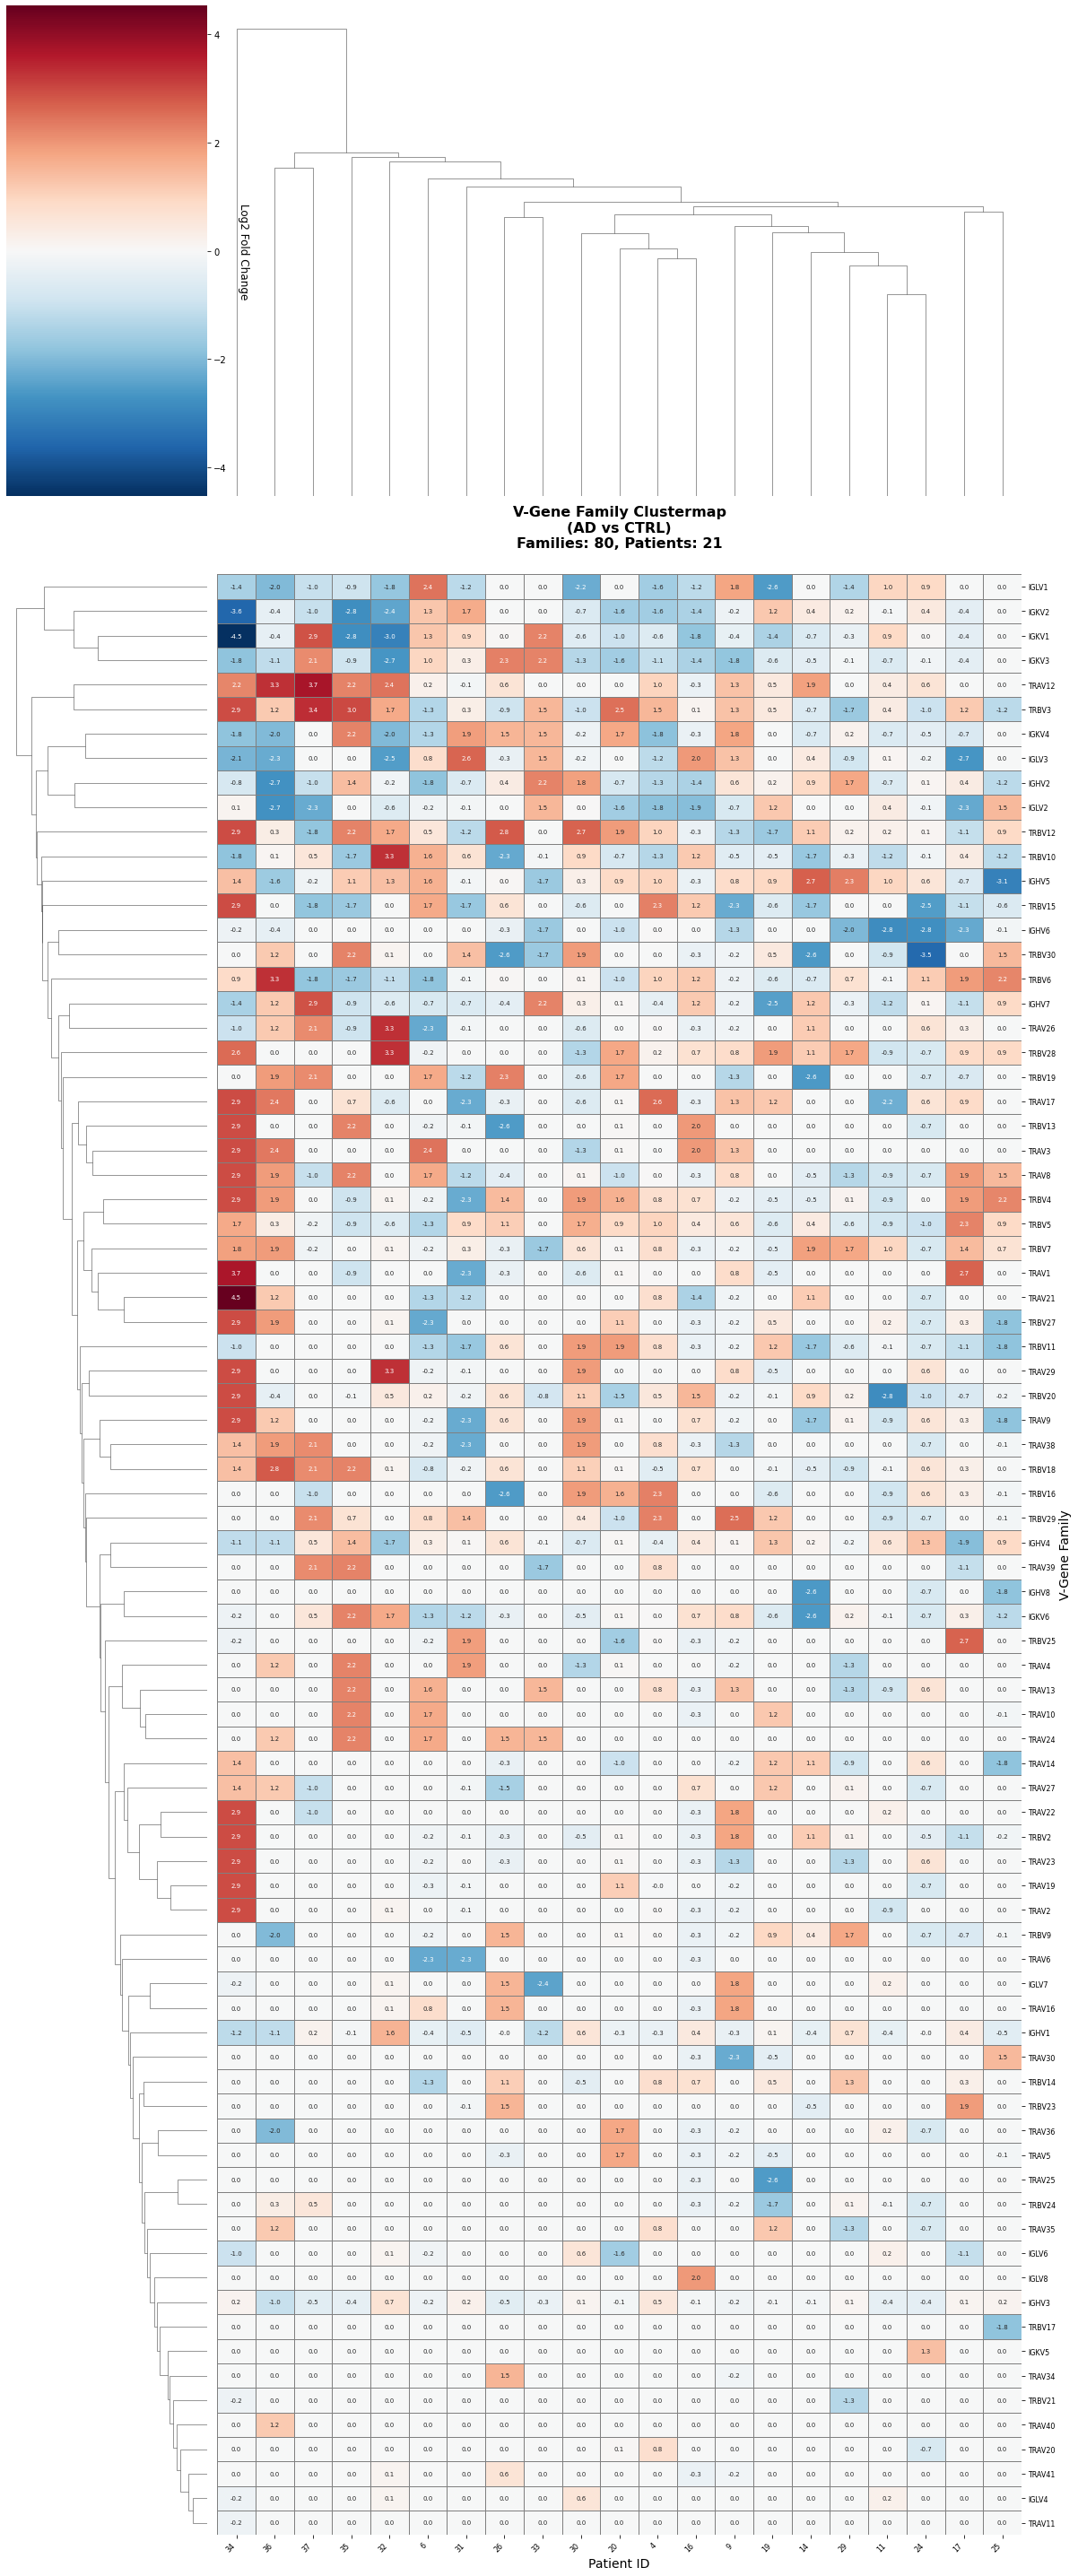


Family Clustermap Summary:
Number of families shown: 80
Number of patients: 21
Annotation font size: 7pt

Top 10 families with highest Log2FC (upregulated):
  TRAV12: mean Log2FC = 0.952
  TRBV3: mean Log2FC = 0.654
  TRBV28: mean Log2FC = 0.610
  TRBV12: mean Log2FC = 0.544
  TRBV4: mean Log2FC = 0.489
  TRAV3: mean Log2FC = 0.467
  TRBV18: mean Log2FC = 0.423
  TRAV29: mean Log2FC = 0.420
  TRBV29: mean Log2FC = 0.415
  IGHV5: mean Log2FC = 0.400

Top 10 families with lowest Log2FC (downregulated):
  TRBV10: mean Log2FC = -0.229
  TRAV6: mean Log2FC = -0.233
  IGHV8: mean Log2FC = -0.246
  TRBV15: mean Log2FC = -0.282
  IGKV3: mean Log2FC = -0.392
  IGKV1: mean Log2FC = -0.460
  IGLV2: mean Log2FC = -0.463
  IGKV2: mean Log2FC = -0.523
  IGLV1: mean Log2FC = -0.532
  IGHV6: mean Log2FC = -0.712

V-GENE LOCUS CLUSTERMAP (AD vs CTRL)


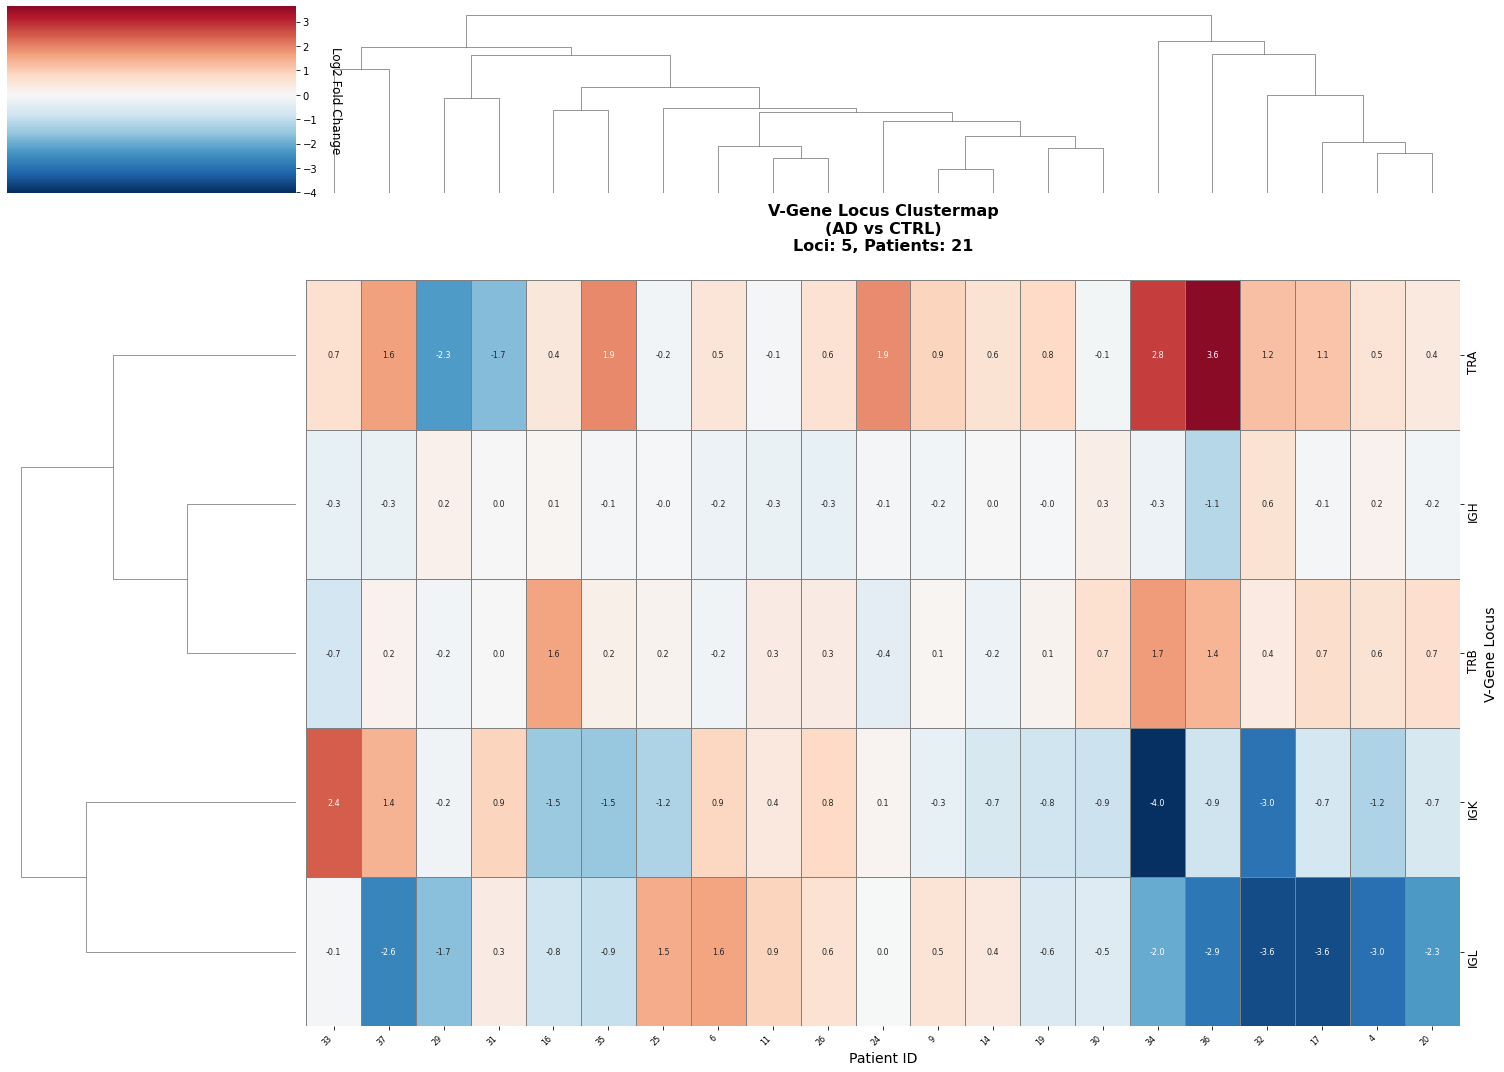


Locus Clustermap Summary:
Number of loci: 5
Number of patients: 21
Annotation font size: 8pt

Top loci with highest Log2FC (upregulated):
  TRA: mean Log2FC = 0.725
  TRB: mean Log2FC = 0.352
  IGH: mean Log2FC = -0.101
  IGK: mean Log2FC = -0.505
  IGL: mean Log2FC = -0.897

Top loci with lowest Log2FC (downregulated):
  TRA: mean Log2FC = 0.725
  TRB: mean Log2FC = 0.352
  IGH: mean Log2FC = -0.101
  IGK: mean Log2FC = -0.505
  IGL: mean Log2FC = -0.897

ANALYSIS COMPLETE FOR AD vs CTRL
Patients analyzed: 21
Comparisons performed: 3
Unique V-gene families: 80
Unique V-gene loci: 5
Output files saved in 'output/' directory

ANALYZING PSO vs CTRL
Analyzing 21 patients...

V-GENE FAMILY CLUSTERMAP (PSO vs CTRL)


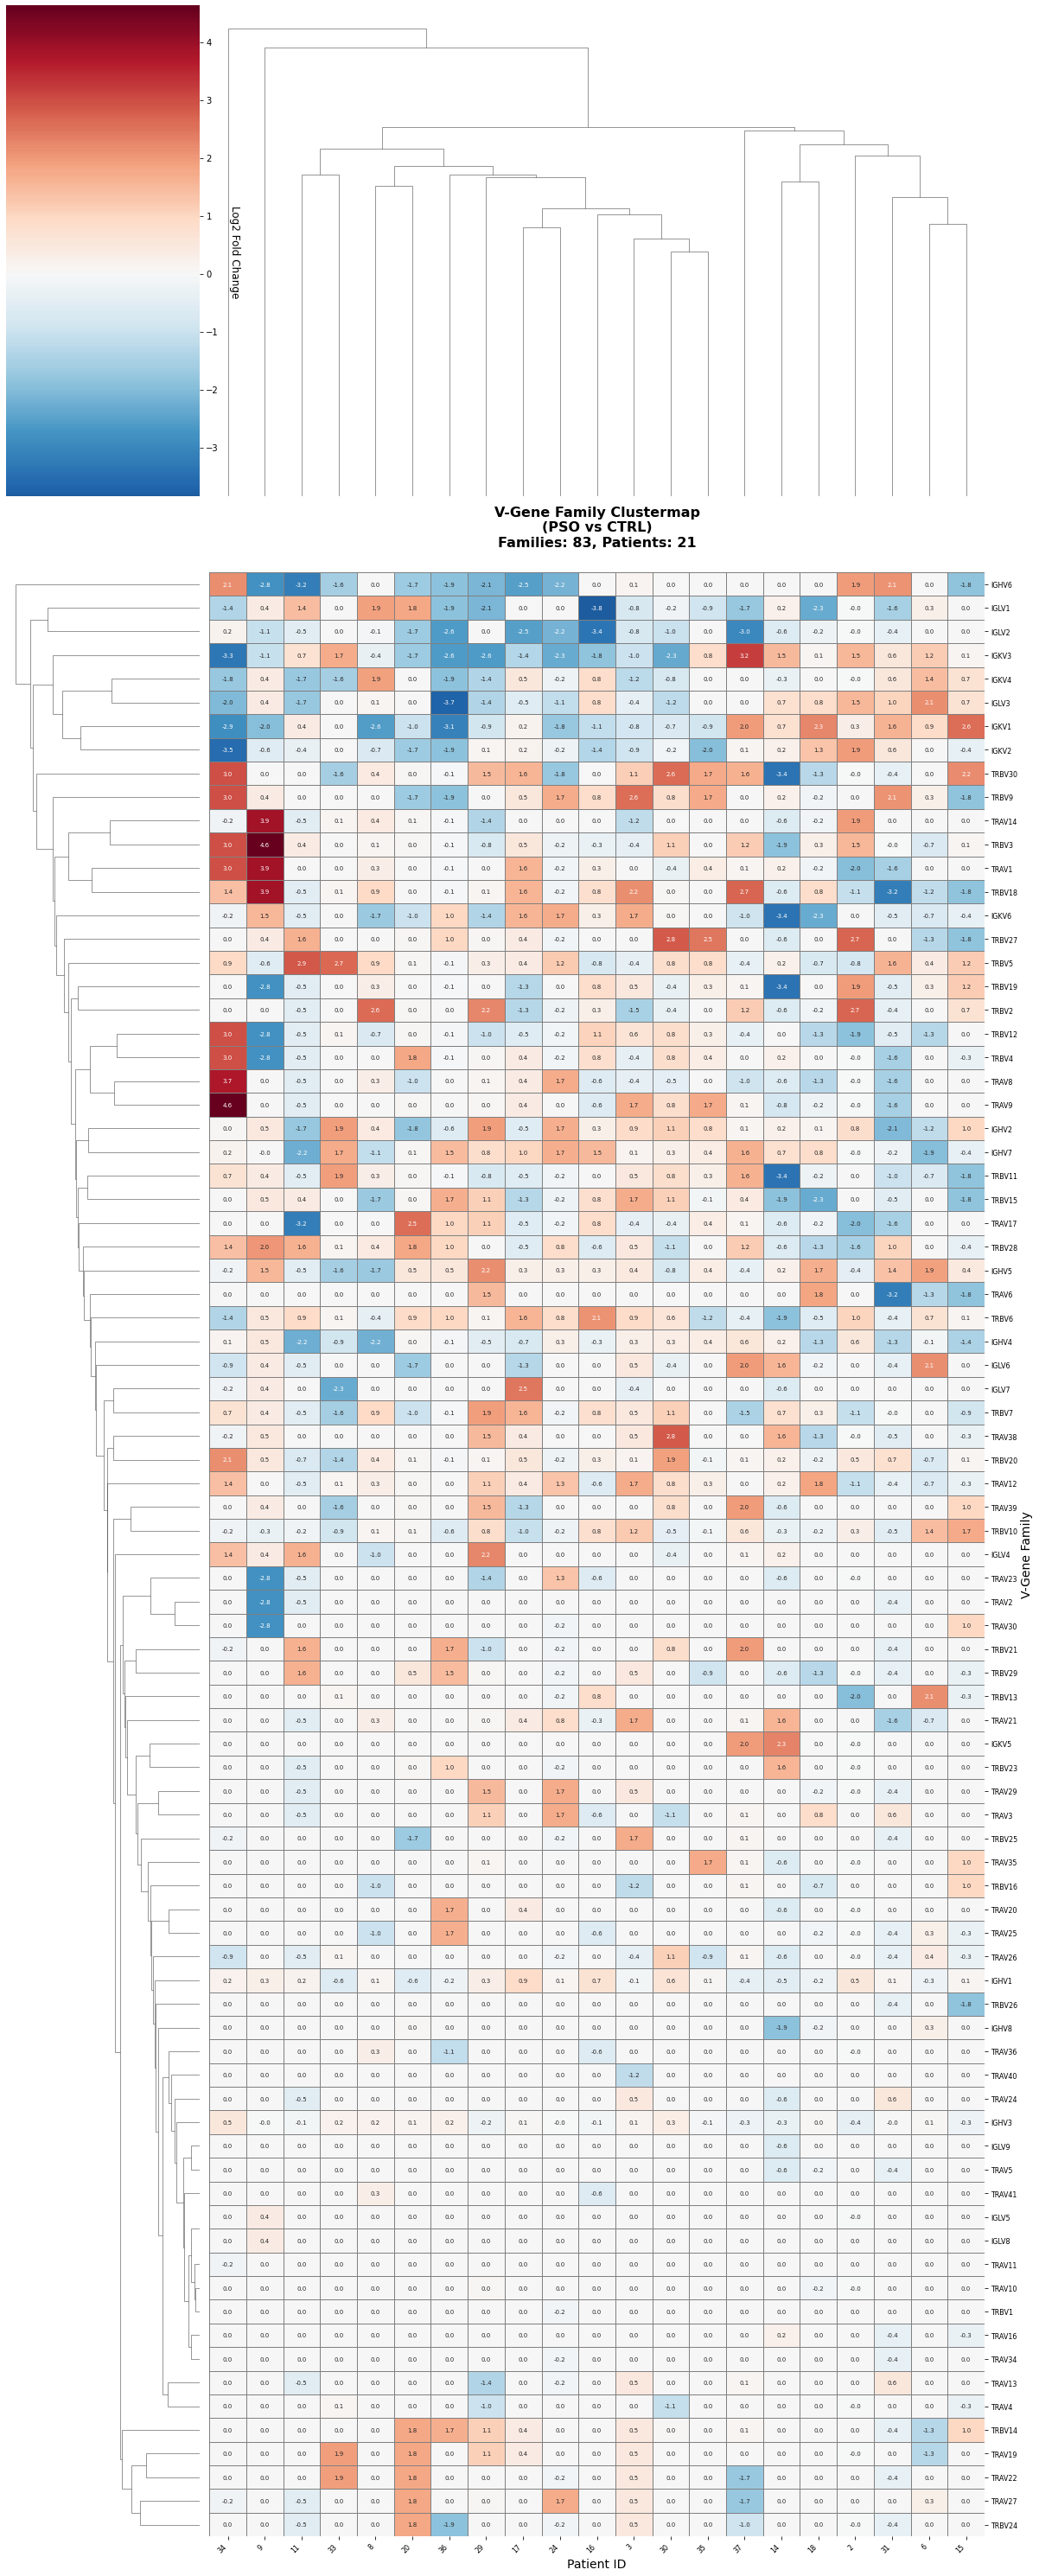


Family Clustermap Summary:
Number of families shown: 83
Number of patients: 21
Annotation font size: 7pt

Top 10 families with highest Log2FC (upregulated):
  TRBV5: mean Log2FC = 0.500
  TRBV9: mean Log2FC = 0.406
  TRBV3: mean Log2FC = 0.402
  TRBV27: mean Log2FC = 0.354
  TRBV30: mean Log2FC = 0.351
  IGHV7: mean Log2FC = 0.308
  IGHV5: mean Log2FC = 0.303
  TRAV12: mean Log2FC = 0.286
  TRBV28: mean Log2FC = 0.277
  TRBV18: mean Log2FC = 0.275

Top 10 families with lowest Log2FC (downregulated):
  IGKV4: mean Log2FC = -0.221
  TRBV12: mean Log2FC = -0.247
  IGKV6: mean Log2FC = -0.253
  IGKV1: mean Log2FC = -0.328
  IGHV4: mean Log2FC = -0.376
  IGKV3: mean Log2FC = -0.433
  IGKV2: mean Log2FC = -0.441
  IGLV1: mean Log2FC = -0.512
  IGHV6: mean Log2FC = -0.641
  IGLV2: mean Log2FC = -0.944

V-GENE LOCUS CLUSTERMAP (PSO vs CTRL)


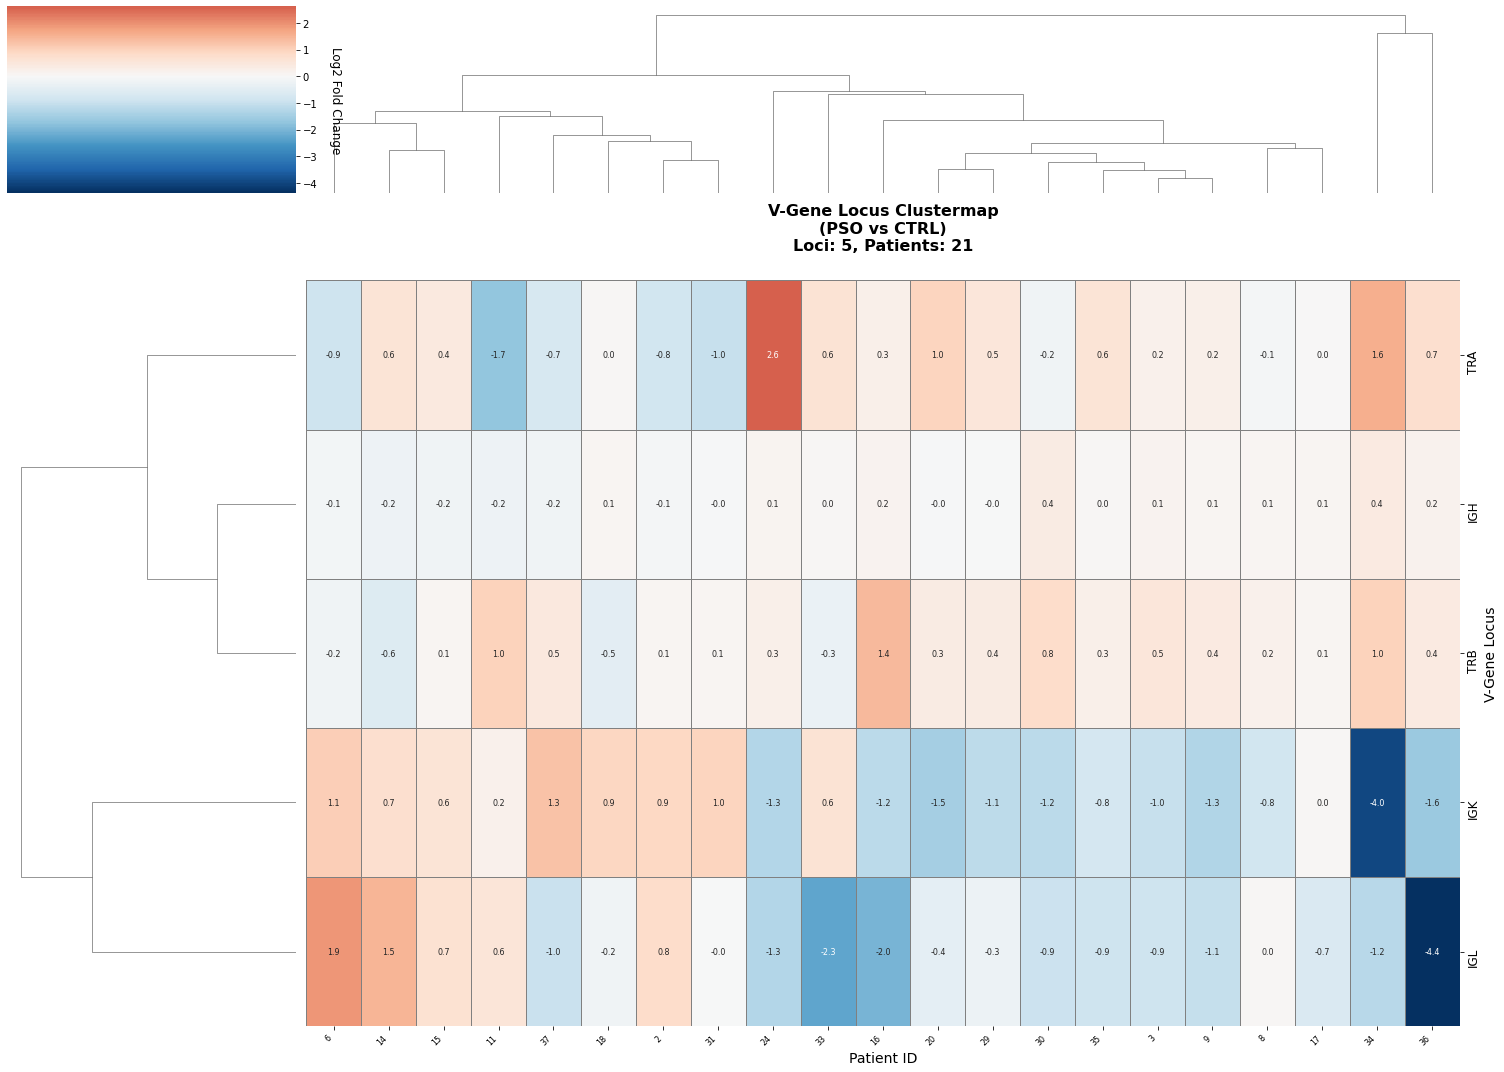


Locus Clustermap Summary:
Number of loci: 5
Number of patients: 21
Annotation font size: 8pt

Top loci with highest Log2FC (upregulated):
  TRB: mean Log2FC = 0.296
  TRA: mean Log2FC = 0.189
  IGH: mean Log2FC = 0.022
  IGK: mean Log2FC = -0.400
  IGL: mean Log2FC = -0.577

Top loci with lowest Log2FC (downregulated):
  TRB: mean Log2FC = 0.296
  TRA: mean Log2FC = 0.189
  IGH: mean Log2FC = 0.022
  IGK: mean Log2FC = -0.400
  IGL: mean Log2FC = -0.577

ANALYSIS COMPLETE FOR PSO vs CTRL
Patients analyzed: 21
Comparisons performed: 3
Unique V-gene families: 83
Unique V-gene loci: 5
Output files saved in 'output/' directory


In [37]:
results_3 = analyze_immune_data_comparison(df)